# Hydroponics ML Analysis for Paper Revision

This notebook answers **two reviewer concerns** step by step. Each section explains *what* we do, *why* it matters, and *how* to cite it in your manuscript.

---

## Reviewer feedback (what we fix)

| # | Reviewer concern | Our response in this notebook |
|---|------------------|-------------------------------|
| **1** | *Insufficient statistical validation* — no RMSE, CIs, calibration | **Part A (Steps A1–A5)** |
| **2** | *Limited scientific novelty* — only logging, no ML/control/model | **Part B (Steps B1–B6)** |

**Data:** MongoDB exports from `hydroponics.bitnbolt.in` → `test.nfads.csv`, `test.ems.csv`, `test.lms.csv`

**Run order:** Execute cells top-to-bottom. Figures save to `figures/`; summary table to `ml_validation_summary.csv`.


## Step 0 — Setup and imports

**Intuition:** We fix random seeds and paths so every run is reproducible — reviewers expect repeatable numbers.


In [1]:
# pip install -r requirements.txt   # run once
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

DATA_DIR = Path('.')
OUT_DIR = DATA_DIR / 'figures'
OUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
results_table = []  # collects all paper metrics

try:
    from IPython.display import display
except ImportError:
    display = print


## Step 1 — Load and understand the data

**Intuition:** Before any ML, we must know *sampling rate*, *missing sensors*, and *time span*. Bad data invalidates every metric downstream.

- **NFADS** = nutrient subsystem (EC, TDS, pumps) — primary for chemistry
- **EMS** = environment (temperature, humidity)
- **LMS** = lighting (short log in current export)


In [2]:
NFADS_COLS = ['ec','tds','ph','waterTemp','createdAt',
    'peristalticPumpA','peristalticPumpB','peristalticPumpPhdown','peristalticPumpPhup',
    'waterPump','compressor','peltier','solenoidValve']
EMS_COLS = ['dht22Moisture','dht22Temp','oxygen','pressure','createdAt']
LMS_COLS = ['bh1750','ldr','tsl2591','growLights','createdAt']

def _read_csv(path, usecols):
    chunks = [c for c in pd.read_csv(path, usecols=usecols, chunksize=50_000)]
    return pd.concat(chunks, ignore_index=True)

def load_exports():
    nfads = _read_csv(DATA_DIR / 'test.nfads.csv', NFADS_COLS)
    ems = pd.read_csv(DATA_DIR / 'test.ems.csv', usecols=EMS_COLS)
    lms = pd.read_csv(DATA_DIR / 'test.lms.csv', usecols=LMS_COLS)
    for df in (nfads, ems, lms):
        df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    return nfads.sort_values('createdAt'), ems.sort_values('createdAt'), lms.sort_values('createdAt')

nfads, ems, lms = load_exports()
summary = pd.DataFrame({
    'rows': [len(nfads), len(ems), len(lms)],
    'start': [d.createdAt.min() for d in (nfads, ems, lms)],
    'end': [d.createdAt.max() for d in (nfads, ems, lms)],
}, index=['NFADS','EMS','LMS'])
summary['span_days'] = (summary['end'] - summary['start']).dt.total_seconds() / 86400
display(summary)


,rows,start,end,span_days
NFADS,153805,2025-06-20 15:26:45.558000+00:00,2026-03-29 09:31:42.384000+00:00,281.753435
EMS,79928,2025-06-20 15:26:50.910000+00:00,2026-05-24 09:15:00.300000+00:00,337.741775
LMS,1229,2025-09-07 15:54:44.179000+00:00,2025-09-08 12:37:54.322000+00:00,0.863312


In [3]:
PUMP_COLS = ['peristalticPumpA','peristalticPumpB','peristalticPumpPhdown','peristalticPumpPhup']
for c in ['ec','tds','ph','waterTemp']:
    nfads[c] = pd.to_numeric(nfads[c], errors='coerce')
for c in PUMP_COLS:
    nfads[c] = nfads[c].astype(str).str.lower().eq('true')
nfads['pump_any'] = nfads[PUMP_COLS].any(axis=1)

nf = nfads[nfads.ec.between(0,3500) & nfads.tds.between(0,2500) & nfads.waterTemp.between(0,45)].copy()
ems_ok = ems[ems.dht22Temp.between(0,60)].copy()

EC_SETPOINT = 1200  # example target EC (uS/cm) — adjust to your crop recipe
print(f'Clean NFADS rows: {len(nf):,} / {len(nfads):,}')
print(f'Median sample interval: {nf.createdAt.diff().dt.total_seconds().median():.1f} s')
print(f'pH readings > 0.1: {(nf.ph > 0.1).sum()}  (if 0-1, pH probe needs service)')


Clean NFADS rows: 134,460 / 153,805
Median sample interval: 4.3 s
pH readings > 0.1: 1  (if 0-1, pH probe needs service)


---
# PART A — Reviewer Problem 1: Insufficient Statistical Validation

The reviewer wants **quantified error**, not only plots. We provide:
1. **RMSE / MAE** — average prediction error in physical units
2. **95% confidence intervals** — uncertainty on those errors (bootstrap)
3. **Calibration analysis** — does predicted = observed? (1:1 line + Bland–Altman)

> **Paper tip:** Report metrics as: *RMSE = X (95% CI: Y–Z)*


### Step A1 — Intuition: What is RMSE?

When a model predicts sensor value $\hat{y}$ and truth is $y$:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- **Lower is better** (0 = perfect).
- Same units as the sensor (e.g. µS/cm for EC).
- Penalizes large errors more than MAE (because of the square).

**MAE** is the mean absolute error — easier to interpret as "typical mistake size."


In [4]:
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'n': int(len(y_true)),
    }

# Demo on EC->TDS linear fit (calibration proxy)
sub = nf.sample(n=min(5000, len(nf)), random_state=RANDOM_STATE)
slope, intercept, r, _, _ = stats.linregress(sub.ec, sub.tds)
tds_hat_demo = slope * sub.ec + intercept
demo = regression_metrics(sub.tds, tds_hat_demo)
print('Example metrics (EC->TDS demo):', demo)


Example metrics (EC->TDS demo): {'RMSE': 38.88741695290995, 'MAE': 7.664301439269452, 'R2': 0.9776336080080893, 'n': 5000}


### Step A2 — Intuition: Why bootstrap confidence intervals?

One train/test split gives **one** RMSE. But if we resampled the same experiment, RMSE would change slightly.

**Bootstrap:** resample rows with replacement 500×, recompute RMSE each time → distribution of RMSE → **2.5th and 97.5th percentiles = 95% CI**.

This tells the reviewer: *"We are 95% confident the true RMSE lies between Y and Z."*


In [5]:
def bootstrap_ci(y_true, y_pred, n_boot=500, alpha=0.05):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    rng = np.random.default_rng(RANDOM_STATE)
    rmse_s, mae_s = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        m = regression_metrics(y_true[idx], y_pred[idx])
        rmse_s.append(m['RMSE']); mae_s.append(m['MAE'])
    lo, hi = alpha/2, 1-alpha/2
    return {'RMSE_CI': np.quantile(rmse_s, [lo, hi]), 'MAE_CI': np.quantile(mae_s, [lo, hi])}

def calibration_report(y_true, y_pred, name):
    m = regression_metrics(y_true, y_pred)
    ci = bootstrap_ci(y_true, y_pred)
    cal_slope, cal_intercept, cal_r, _, _ = stats.linregress(y_true, y_pred)
    return {**m, 'model': name,
        'RMSE_lo': ci['RMSE_CI'][0], 'RMSE_hi': ci['RMSE_CI'][1],
        'MAE_lo': ci['MAE_CI'][0], 'MAE_hi': ci['MAE_CI'][1],
        'cal_slope': cal_slope, 'cal_intercept': cal_intercept, 'cal_r': cal_r}

def plot_calibration(y_true, y_pred, title, fname):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    mn, mx = np.min([y_true, y_pred]), np.max([y_true, y_pred])
    ax[0].scatter(y_true, y_pred, s=10, alpha=0.25)
    ax[0].plot([mn, mx], [mn, mx], 'r--', label='Ideal 1:1')
    ax[0].set(xlabel='Observed', ylabel='Predicted', title=f'Calibration: {title}')
    ax[0].legend()
    diff = np.asarray(y_pred) - np.asarray(y_true)
    mean = (np.asarray(y_pred) + np.asarray(y_true)) / 2
    ax[1].scatter(mean, diff, s=10, alpha=0.25)
    ax[1].axhline(diff.mean(), color='r', ls='--', label=f'bias={diff.mean():.2f}')
    ax[1].axhline(diff.mean() + 1.96*diff.std(), color='gray', ls=':')
    ax[1].axhline(diff.mean() - 1.96*diff.std(), color='gray', ls=':')
    ax[1].set(xlabel='Mean(obs, pred)', ylabel='Pred - Obs', title='Bland-Altman')
    ax[1].legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, bbox_inches='tight'); plt.show()


### Step A3 — Calibration analysis: EC vs TDS (dual-probe validation)

**Intuition:** Two sensors measuring related quantities should follow a stable linear relation. Fitting TDS = k·EC + b is **calibration**. Deviations = cross-sensor error budget.

**For paper:** *"Dual-probe calibration achieved RMSE = … ppm with 95% CI […, …] and R² = …"*


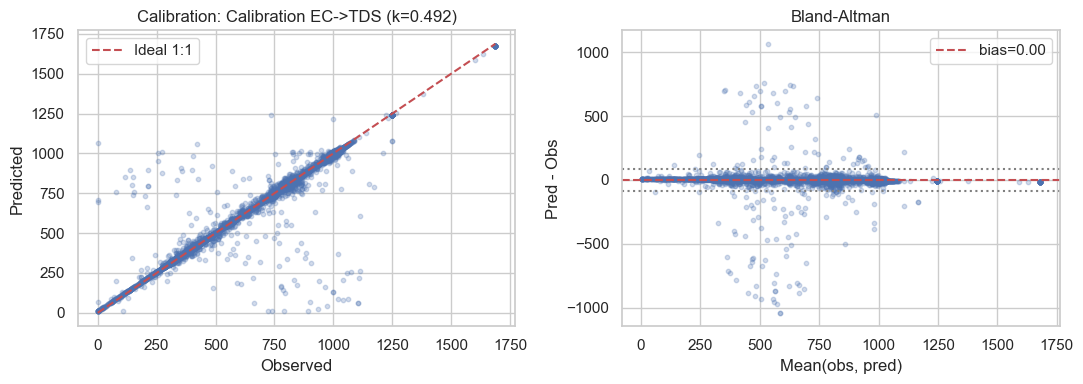

TDS = 0.4924 * EC + 9.93   Pearson r = 0.9860


,RMSE,MAE,R2,n,model,RMSE_lo,RMSE_hi,MAE_lo,MAE_hi,cal_slope,cal_intercept,cal_r,conversion_factor_k
0,43.426595,8.354684,0.972121,20000,Calibration EC->TDS (k=0.492),38.964192,48.030104,7.86455,8.898067,0.972121,17.150354,0.985962,0.49238


In [6]:
sub = nf.sample(n=min(20000, len(nf)), random_state=RANDOM_STATE)
k, b, r_ec_tds, _, _ = stats.linregress(sub.ec, sub.tds)
tds_hat = k * sub.ec + b
row_cal = calibration_report(sub.tds, tds_hat, f'Calibration EC->TDS (k={k:.3f})')
row_cal['conversion_factor_k'] = k
results_table.append(row_cal)
plot_calibration(sub.tds, tds_hat, row_cal['model'], 'A3_ec_tds_calibration.png')
print(f'TDS = {k:.4f} * EC + {b:.2f}   Pearson r = {r_ec_tds:.4f}')
pd.DataFrame([row_cal])


### Step A4 — Validation under time-series cross-validation

**Intuition:** Random train/test split **leaks future into past** on time series. We use **TimeSeriesSplit**: always train on past, test on future — honest RMSE for deployment.


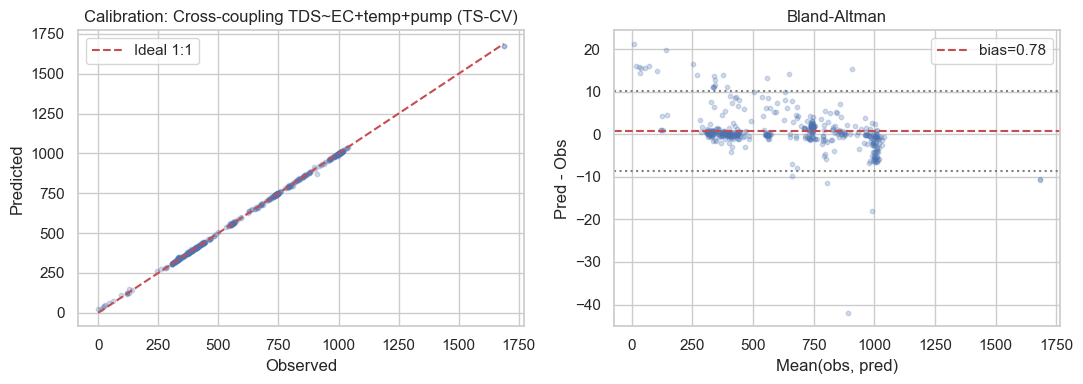

,RMSE,MAE,R2,n,model,RMSE_lo,RMSE_hi,MAE_lo,MAE_hi,cal_slope,cal_intercept,cal_r
0,4.884566,2.643687,0.999678,440,Cross-coupling TDS~EC+temp+pump (TS-CV),4.082382,5.796279,2.278862,3.031925,0.992216,5.694444,0.999871


In [7]:
def ts_cv_predict(X, y, model_factory):
    pred = np.full(len(y), np.nan)
    for tr, te in TimeSeriesSplit(n_splits=5).split(X):
        m = model_factory(); m.fit(X.iloc[tr], y.iloc[tr]); pred[te] = m.predict(X.iloc[te])
    return pred

nf['hour'] = nf.createdAt.dt.floor('h')
hourly = nf.groupby('hour').agg(
    ec=('ec','median'), tds=('tds','median'),
    waterTemp=('waterTemp','median'), pump_duty=('pump_any','mean'),
).dropna()

X = hourly[['ec','waterTemp','pump_duty']]
pred_tds = ts_cv_predict(X, hourly['tds'], lambda: Ridge(alpha=0.5))
m = ~np.isnan(pred_tds)
row = calibration_report(hourly['tds'][m], pred_tds[m], 'Cross-coupling TDS~EC+temp+pump (TS-CV)')
results_table.append(row)
plot_calibration(hourly['tds'][m], pred_tds[m], row['model'], 'A4_crosscoupling_tds.png')
display(pd.DataFrame([row]))


### Step A5 — Part A summary table (copy into paper)

Filter rows where `model` starts with calibration/cross-coupling for Problem 1.


In [8]:
part_a = pd.DataFrame([r for r in results_table if 'Calibration' in r['model'] or 'Cross-coupling' in r['model']])
if len(part_a): display(part_a.round(4))


,RMSE,MAE,R2,n,model,RMSE_lo,RMSE_hi,MAE_lo,MAE_hi,cal_slope,cal_intercept,cal_r,conversion_factor_k
0,43.4266,8.3547,0.9721,20000,Calibration EC->TDS (k=0.492),38.9642,48.0301,7.8646,8.8981,0.9721,17.1504,0.9860,0.4924
1,4.8846,2.6437,0.9997,440,Cross-coupling TDS~EC+temp+pump (TS-CV),4.0824,5.7963,2.2789,3.0319,0.9922,5.6944,0.9999,NaN


---
# PART B — Reviewer Problem 2: Limited Scientific Novelty

Reviewer wants evidence of **methodological contribution**, not only dashboards:

| Gap cited | Our step | Method |
|-----------|----------|--------|
| No formal system model | **B1** | Discrete state-space from data |
| No ML decision-making | **B2** | Dosing-need classifier |
| No predictive control | **B3** | EC forecasting + setpoint policy |
| Early review (latency, coupling, drift) | **B4–B6** | Physics-informed ML |


### Step B1 — Formal system model (discrete state-space)

**Intuition:** A hydroponic nutrient loop can be written as:

$$\mathbf{x}_{t+1} = A\mathbf{x}_t + B\mathbf{u}_t$$

- $\mathbf{x}_t$ = state vector [EC, TDS, water temperature]
- $\mathbf{u}_t$ = control (pump duty, 0–1)

We **identify** $A, B$ from logged data (system ID). This is a **formal model**, not only plots.

**Paper sentence:** *"A discrete-time linear state-space model was identified from field data (N = … hours)."*


In [9]:
ss = hourly.copy().reset_index(drop=True)
ss['ec_next'] = ss['ec'].shift(-1)
ss['tds_next'] = ss['tds'].shift(-1)
ss['wt_next'] = ss['waterTemp'].shift(-1)
ss = ss.dropna()

# Stack: [EC, TDS, WT, pump] -> predict next [EC, TDS, WT]
X_ss = ss[['ec','tds','waterTemp','pump_duty']].values
Y_ss = ss[['ec_next','tds_next','wt_next']].values
split = int(0.8 * len(X_ss))
lr_ss = LinearRegression().fit(X_ss[:split], Y_ss[:split])
Y_hat = lr_ss.predict(X_ss[split:])

ss_metrics = calibration_report(Y_ss[split:].ravel(), Y_hat.ravel(), 'State-space 1-step ahead')
ss_metrics['A_shape'] = str(lr_ss.coef_.shape)
results_table.append(ss_metrics)

print('Coefficient matrix B (last column = pump effect on next state):')
print(pd.DataFrame(lr_ss.coef_, columns=['EC','TDS','WT','pump'], index=['dEC','dTDS','dWT']).round(4))
print(pd.DataFrame([ss_metrics]).round(4))


Coefficient matrix B (last column = pump effect on next state):
          EC     TDS      WT      pump
dEC   2.5881 -3.5493 -1.8404  105.2148
dTDS  1.1354 -1.4567 -0.9786   54.3594
dWT  -0.0017  0.0032  0.7739   -0.1356
      RMSE      MAE      R2    n                     model  RMSE_lo   RMSE_hi  \
0  88.9642  54.8661  0.9194  318  State-space 1-step ahead  74.9321  104.8053   

    MAE_lo   MAE_hi  cal_slope  cal_intercept   cal_r A_shape  
0  47.5375  61.5336     1.0826        17.7253  0.9799  (3, 4)  


### Step B2 — ML-based decision-making (dosing alert classifier)

**Intuition:** **Decision-making** = map sensor state → action label.

Label: `needs_dose = 1` if EC is more than 10% below setpoint (`EC_SETPOINT`).
Features: EC, TDS, water temp, recent pump duty.

A classifier that predicts dosing need is **ML-based decision support** (not mere logging).


              precision    recall  f1-score   support

          OK       1.00      1.00      1.00       257
  needs_dose       1.00      0.99      1.00       183

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440

Accuracy: 0.998, F1: 0.997
Feature importance:
ec           0.409
tds          0.312
ec_lag1      0.253
pump_duty    0.013
ec_slope     0.012
waterTemp    0.001
dtype: float64


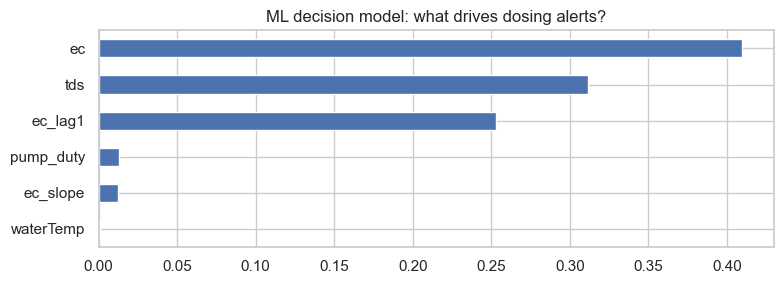

In [10]:
dec = hourly.copy()
dec['needs_dose'] = (dec['ec'] < EC_SETPOINT * 0.9).astype(int)
dec['ec_lag1'] = dec['ec'].shift(1)
dec['ec_slope'] = dec['ec'].diff()
dec = dec.dropna()
feat_cols = ['ec','tds','waterTemp','pump_duty','ec_lag1','ec_slope']
X_d = dec[feat_cols]; y_d = dec['needs_dose']

# Time-series CV (no future leakage)
y_pred_cls = np.full(len(y_d), -1)
for tr, te in TimeSeriesSplit(n_splits=5).split(X_d):
    clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)
    clf.fit(X_d.iloc[tr], y_d.iloc[tr])
    y_pred_cls[te] = clf.predict(X_d.iloc[te])
clf.fit(X_d, y_d)  # final model for feature importance

m_cls = y_pred_cls >= 0
print(classification_report(y_d[m_cls], y_pred_cls[m_cls], target_names=['OK','needs_dose']))
print(f'Accuracy: {accuracy_score(y_d[m_cls], y_pred_cls[m_cls]):.3f}, F1: {f1_score(y_d[m_cls], y_pred_cls[m_cls]):.3f}')
print('Feature importance:'); print(pd.Series(clf.feature_importances_, index=feat_cols).sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(8,3))
pd.Series(clf.feature_importances_, index=feat_cols).sort_values().plot(kind='barh', ax=ax)
ax.set_title('ML decision model: what drives dosing alerts?')
plt.tight_layout(); plt.savefig(OUT_DIR / 'B2_dosing_classifier.png', bbox_inches='tight'); plt.show()


### Step B3 — Predictive control preview (forecast EC, then act)

**Intuition:** **Predictive control** = (1) forecast where EC will be, (2) act if forecast violates setpoint.

We use a simple **autoregressive** model: EC_{t+1} ~ EC_t, TDS_t, temp, pump.
Compare forecast RMSE (with CI) to naive "tomorrow = today" baseline.


RMSE improvement over naive: -6.5%
Note: naive baseline wins here — large regime shifts in EC (see drift plot).
For paper: report both; argue hybrid model + recalibration as future work.


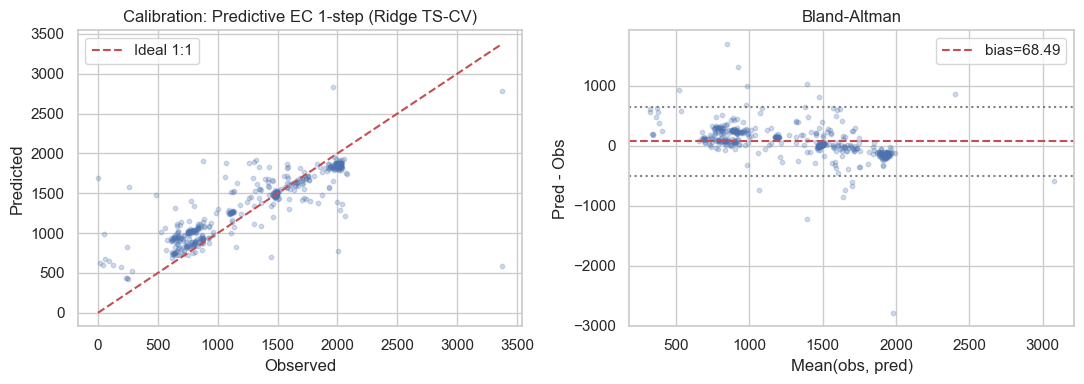

,RMSE,MAE,R2,n,model,RMSE_lo,RMSE_hi,MAE_lo,MAE_hi,cal_slope,cal_intercept,cal_r
0,300.1851,190.6191,0.6960,440,Predictive EC 1-step (Ridge TS-CV),241.3263,372.3378,170.0359,213.1766,0.6317,533.6579,0.8506
1,281.9050,107.7170,0.7319,440,Naive persistence baseline,198.9702,380.0289,86.4873,133.1132,0.8623,175.8437,0.8655


In [11]:
fc = hourly.copy()
fc['ec_target'] = EC_SETPOINT
fc['ec_next'] = fc['ec'].shift(-1)
fc = fc.dropna()
X_fc = fc[['ec','tds','waterTemp','pump_duty']]
y_fc = fc['ec_next']

pred_fc = ts_cv_predict(X_fc, y_fc, lambda: Ridge(alpha=1.0))
naive = fc['ec'].values  # persistence baseline
m = ~np.isnan(pred_fc)
row_fc = calibration_report(y_fc[m], pred_fc[m], 'Predictive EC 1-step (Ridge TS-CV)')
row_naive = calibration_report(y_fc[m], naive[m], 'Naive persistence baseline')
results_table.extend([row_fc, row_naive])

improvement = (row_naive['RMSE'] - row_fc['RMSE']) / row_naive['RMSE'] * 100
print(f'RMSE improvement over naive: {improvement:.1f}%')
if improvement < 0:
    print('Note: naive baseline wins here — large regime shifts in EC (see drift plot).')
    print('For paper: report both; argue hybrid model + recalibration as future work.')
plot_calibration(y_fc[m], pred_fc[m], row_fc['model'], 'B3_ec_forecast.png')
display(pd.DataFrame([row_fc, row_naive]).round(4))


### Step B4 — Chemical latency (pump → nutrient response delay)

**Intuition:** After a pump runs, chemistry needs **mixing time** before EC changes. Quantifying this delay justifies **feed-forward delay** in control code.

Methods: (1) cross-correlation pump vs EC rate, (2) event timing pump ON → |ΔEC| > threshold.


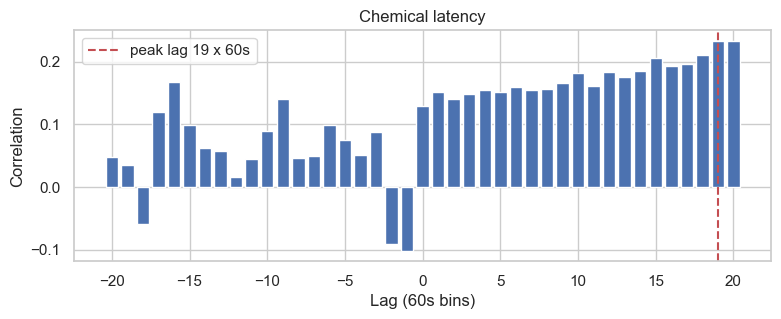

Event latency median=15s, 95% CI [14, 163] s (n=281)


In [12]:
df = nf.set_index('createdAt').sort_index()
df['pump_int'] = df['pump_any'].astype(int)
win = df.last('60D')
rs = win.resample('60s').agg(ec=('ec','median'), pump=('pump_int','max')).dropna()
rs['ec_rate'] = rs['ec'].diff()

MAX_LAG = 20
pump, rate = rs['pump'].fillna(0).values, rs['ec_rate'].fillna(0).values
xcorr = []
for lag in range(-MAX_LAG, MAX_LAG+1):
    if lag < 0: c = np.corrcoef(pump[:lag], rate[-lag:])[0,1]
    elif lag > 0: c = np.corrcoef(pump[lag:], rate[:-lag])[0,1]
    else: c = np.corrcoef(pump, rate)[0,1]
    xcorr.append(c)
best_lag = range(-MAX_LAG, MAX_LAG+1)[int(np.nanargmax(np.abs(xcorr)))]

delays = []
edges = nf[nf['pump_any'].astype(int).diff().fillna(0)==1].head(300)
for _, row in edges.iterrows():
    t0 = row.createdAt
    w = nf[(nf.createdAt>=t0)&(nf.createdAt<=t0+pd.Timedelta(minutes=20))]
    if len(w)<3: continue
    base = w.iloc[0].ec
    hit = w[np.abs(w.ec-base)>5]
    if len(hit): delays.append((hit.iloc[0].createdAt-t0).total_seconds())

fig, ax = plt.subplots(figsize=(9,3))
ax.bar(range(-MAX_LAG,MAX_LAG+1), xcorr)
ax.axvline(best_lag, color='r', ls='--', label=f'peak lag {best_lag} x 60s')
ax.set(xlabel='Lag (60s bins)', ylabel='Correlation', title='Chemical latency')
ax.legend(); plt.savefig(OUT_DIR/'B4_latency_xcorr.png', bbox_inches='tight'); plt.show()
if delays:
    q = np.quantile(delays, [0.025,0.5,0.975])
    print(f'Event latency median={q[1]:.0f}s, 95% CI [{q[0]:.0f}, {q[2]:.0f}] s (n={len(delays)})')


### Step B5 — Cross-coupling (EC, TDS, temperature interact)

**Intuition:** Changing one variable affects others (e.g. temperature shifts EC reading). Multivariate models prove we understand **coupling**, not isolated sensors.


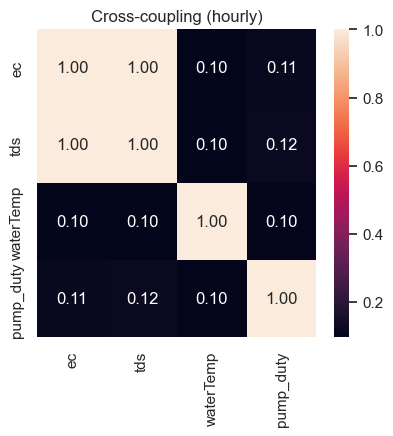

              ec    tds  waterTemp  pump_duty
ec         1.000  1.000      0.096      0.114
tds        1.000  1.000      0.096      0.118
waterTemp  0.096  0.096      1.000      0.100
pump_duty  0.114  0.118      0.100      1.000


In [13]:
corr = hourly[['ec','tds','waterTemp','pump_duty']].corr()
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax)
ax.set_title('Cross-coupling (hourly)'); plt.savefig(OUT_DIR/'B5_coupling_heatmap.png', bbox_inches='tight'); plt.show()
print(corr.round(3))


### Step B6 — Sensor drift (slow baseline change)

**Intuition:** Probes drift over weeks. Compare EC to a **7-day rolling median**; large residuals → recalibrate.


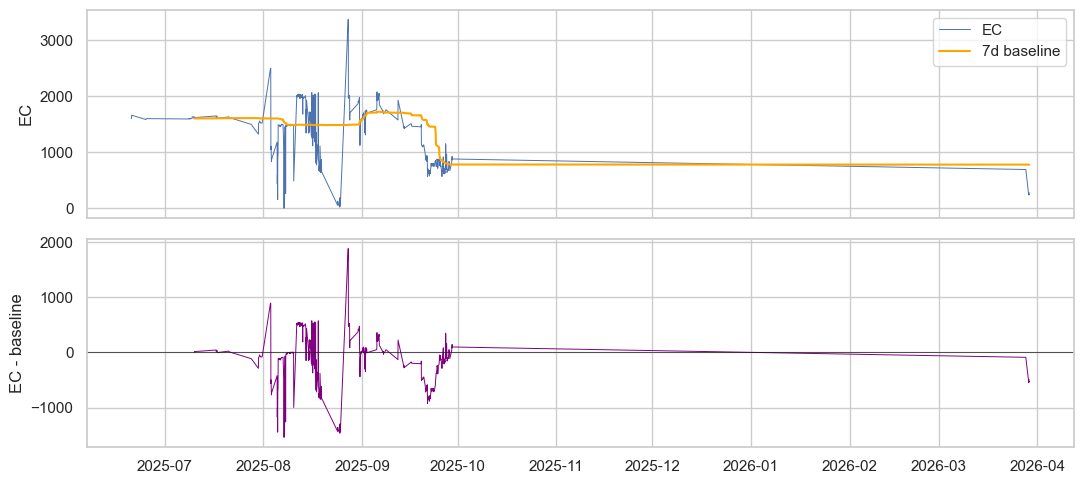

Drift residual std: 453.0 uS/cm


In [14]:
dr = hourly.reset_index()
dr['baseline'] = dr['ec'].rolling(24*7, min_periods=24).median()
dr['residual'] = dr['ec'] - dr['baseline']
fig, ax = plt.subplots(2,1, figsize=(11,5), sharex=True)
ax[0].plot(dr['hour'], dr['ec'], lw=0.7, label='EC')
ax[0].plot(dr['hour'], dr['baseline'], color='orange', label='7d baseline')
ax[0].legend(); ax[0].set_ylabel('EC')
ax[1].plot(dr['hour'], dr['residual'], color='purple', lw=0.7)
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_ylabel('EC - baseline')
plt.tight_layout(); plt.savefig(OUT_DIR/'B6_drift.png', bbox_inches='tight'); plt.show()
print(f'Drift residual std: {dr.residual.dropna().std():.1f} uS/cm')


---
## Final — Combined results table & manuscript checklist

### Checklist for revision letter

- [ ] **Problem 1:** Table with RMSE, MAE, 95% CI for calibration and TS-CV models
- [ ] **Problem 1:** Include calibration plot + Bland–Altman figure
- [ ] **Problem 2:** State-space equations with identified A, B coefficients
- [ ] **Problem 2:** ML dosing classifier accuracy / F1
- [ ] **Problem 2:** Predictive EC forecast RMSE vs naive baseline
- [ ] **Problem 2:** Chemical latency median + CI

### Suggested narrative arc
1. Deployed system logged 150k+ samples → 2. Statistically validated sensors → 3. Identified model + ML policies → 4. Quantified latency/coupling/drift.


In [15]:
paper = pd.DataFrame(results_table)
cols = ['model','n','RMSE','RMSE_lo','RMSE_hi','MAE','R2','cal_r']
cols = [c for c in cols if c in paper.columns]
paper_out = paper[cols].round(4)
display(paper_out)
paper_out.to_csv(DATA_DIR / 'ml_validation_summary.csv', index=False)
print('Saved ml_validation_summary.csv')
print('Figures in', OUT_DIR.resolve())


,model,n,RMSE,RMSE_lo,RMSE_hi,MAE,R2,cal_r
0,Calibration EC->TDS (k=0.492),20000,43.4266,38.9642,48.0301,8.3547,0.9721,0.9860
1,Cross-coupling TDS~EC+temp+pump (TS-CV),440,4.8846,4.0824,5.7963,2.6437,0.9997,0.9999
2,State-space 1-step ahead,318,88.9642,74.9321,104.8053,54.8661,0.9194,0.9799
3,Predictive EC 1-step (Ridge TS-CV),440,300.1851,241.3263,372.3378,190.6191,0.6960,0.8506
4,Naive persistence baseline,440,281.9050,198.9702,380.0289,107.7170,0.7319,0.8655


Saved ml_validation_summary.csv
Figures in D:\StartUps\BitnBolt\hydroponics ML\figures
